In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from matplotlib.lines import Line2D
from scipy.stats import bootstrap

In [2]:
bins = pd.read_csv('../../../SRB_analysis/data/merged_covariates.csv') # utilize covariates table from SRB analysis
events_df = pd.read_csv('../results/hotspot_event_definitions.csv')
clustered_svs = pd.read_csv('../results/all_samples_clustering_regions.txt', sep='\t')
bins.head()

,bin_id,chrom,start,end,replication_timing,gc_content,mappability,frac_heterochromatin,gene_density,frac_fragile_site,breakpoint_count,frac_sine,frac_line,frac_ltr
0,0,1,25000,75000,0.228249,-0.310924,-7.091714,-0.462759,3.904444,1.323585,1.0,-0.727919,-0.069211,-0.209417
1,1,1,75000,125000,0.190545,-0.434277,-7.278499,-0.282773,0.505917,1.323585,0.0,-0.263260,1.076090,-0.005731
2,3,1,375000,425000,0.067359,0.583692,-10.619320,-0.615054,-1.193347,1.323585,0.0,0.022927,-0.137056,0.172940
3,4,1,425000,475000,0.049794,-0.561390,-9.024493,-0.615054,-0.060505,1.323585,0.0,-1.125178,2.496487,0.214722
4,6,1,675000,725000,0.362343,-0.454804,-8.847729,-0.615054,1.638759,1.323585,0.0,-0.699153,0.925686,0.153698


In [3]:
# Parse hotspot regions
events = events_df.set_index('event')[['chrom', 'start', 'end']].to_dict(orient='index')
hotspot_regions = [(v['chrom'], v['start'], v['end']) for v in events.values()] # (chrom, start, end) tuples

# Parse clustered SV regions (excluding hotspots)
clustered_svs['chrom_norm'] = clustered_svs['chr'].astype(str).str.replace('chr', '')
clustered_regions = list(zip(
    clustered_svs['chrom_norm'],
    clustered_svs['start.bp'],
    clustered_svs['end.bp']
))

# Label bins according to their category
def overlaps(bin_chrom, bin_start, bin_end, regions):
    for chrom, start, end in regions:
        if str(bin_chrom) == str(chrom) and bin_start < end and bin_end > start:
            return True
    return False

def label_bin(row):
    # Check hotspot first 
    if overlaps(row['chrom'], row['start'], row['end'], hotspot_regions):
        return 'hotspot'
    # Then check clustered SV background
    if overlaps(row['chrom'], row['start'], row['end'], clustered_regions):
        return 'sv_background'
    return 'null'

bins['group'] = bins.apply(label_bin, axis=1)

print(bins['group'].value_counts())
print("\nHotspot bins per event:")

for event_name, coords in events.items():
    n = bins[
        (bins['chrom'].astype(str) == str(coords['chrom'])) &
        (bins['start'] < coords['end']) &
        (bins['end'] > coords['start'])
    ].shape[0]
    print(f"  {event_name}: {n} bins")

group
sv_background    38879
null             15114
hotspot           1924
Name: count, dtype: int64

Hotspot bins per event:
  CCND3: 317 bins
  MYC: 750 bins
  CDK4-MDM2: 440 bins
  CCNE1: 128 bins
  TP53: 289 bins


In [4]:
features = ["replication_timing", "gc_content", "frac_heterochromatin", "gene_density", "frac_sine", "frac_line", "frac_ltr"]

hotspot_bins  = bins[bins["group"] == "hotspot"]
bg_bins       = bins[bins["group"] == "sv_background"]
clustered_bins = bins[bins["group"].isin(["hotspot", "sv_background"])]
void_bins     = bins[bins["group"] == "null"]

results = []
for feat in features:
    h  = hotspot_bins[feat].dropna()
    bg = bg_bins[feat].dropna()
    cl = clustered_bins[feat].dropna()
    vd = void_bins[feat].dropna()

    stat_bg, pval_bg = stats.mannwhitneyu(h,  bg, alternative="two-sided")
    stat_vd, pval_vd = stats.mannwhitneyu(cl, vd, alternative="two-sided")

    r_bg = 2 * stat_bg / (len(h)  * len(bg)) - 1
    r_vd = 2 * stat_vd / (len(cl) * len(vd)) - 1

    results.append({
        "feature":                feat,
        "hotspot_mean":           h.mean(),
        "sv_bg_mean":             bg.mean(),
        "clustered_mean":         cl.mean(),
        "void_mean":              vd.mean(),
        "pval_vs_bg":             pval_bg,
        "effect_r_vs_bg":         r_bg,
        "pval_clustered_vs_void": pval_vd,
        "effect_r_clustered_vs_void": r_vd,
    })

results_df = pd.DataFrame(results)

_, results_df["qval_vs_bg"],             _, _ = multipletests(results_df["pval_vs_bg"],             method="fdr_bh")
_, results_df["qval_clustered_vs_void"], _, _ = multipletests(results_df["pval_clustered_vs_void"], method="fdr_bh")

pd.set_option("display.float_format", "{:.3e}".format)
print(results_df[[
    "feature",
    "hotspot_mean", "sv_bg_mean", "clustered_mean", "void_mean",
    "pval_vs_bg", "qval_vs_bg", "effect_r_vs_bg",
    "pval_clustered_vs_void", "qval_clustered_vs_void", "effect_r_clustered_vs_void"
]])

                feature  hotspot_mean  sv_bg_mean  clustered_mean  void_mean  \
0    replication_timing     7.806e-02   2.231e-02       2.494e-02 -6.733e-02   
1            gc_content    -7.013e-03  -3.738e-03      -3.893e-03  1.051e-02   
2  frac_heterochromatin    -4.471e-03  -1.190e-02      -1.155e-02  3.118e-02   
3          gene_density     3.488e-02  -7.299e-03      -5.310e-03  1.434e-02   
4             frac_sine     3.338e-02   5.195e-03       6.524e-03 -1.761e-02   
5             frac_line    -5.441e-02  -6.199e-02      -6.163e-02  1.664e-01   
6              frac_ltr    -1.099e-02  -1.919e-02      -1.881e-02  5.077e-02   

   pval_vs_bg  qval_vs_bg  effect_r_vs_bg  pval_clustered_vs_void  \
0   2.820e-02   9.871e-02       2.959e-02               5.283e-21   
1   3.969e-01   4.630e-01       1.142e-02               8.259e-03   
2   1.270e-01   2.964e-01       1.967e-02               3.586e-01   
3   8.388e-01   8.388e-01       2.662e-03               7.522e-01   
4   8.539e-05 

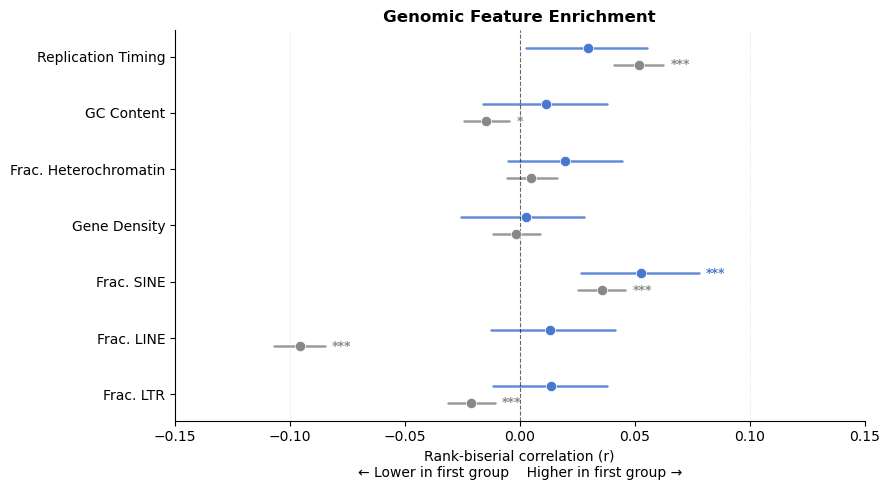

In [5]:
features = [
    "replication_timing", "gc_content",
    "frac_heterochromatin", "gene_density",
    "frac_sine", "frac_line", "frac_ltr"
]
feature_labels = {
    "replication_timing":   "Replication Timing",
    "gc_content":           "GC Content",
    "frac_heterochromatin": "Frac. Heterochromatin",
    "gene_density":         "Gene Density",
    "frac_sine":            "Frac. SINE",
    "frac_line":            "Frac. LINE",
    "frac_ltr":             "Frac. LTR",
}

palette = {
    "vs_bg":   "#4878d0",
    "vs_void": "#888888",
}
comparison_labels = {
    "vs_bg":   "Hotspot vs. SV Background",
    "vs_void": "All Clustered SV vs. SV-void",
}
y_jitter = {"vs_bg": 0.15, "vs_void": -0.15}

h_bins        = bins[bins["group"] == "hotspot"]
bg_bins       = bins[bins["group"] == "sv_background"]
clustered_bins = bins[bins["group"].isin(["hotspot", "sv_background"])]
void_bins     = bins[bins["group"] == "null"]

def rank_biserial_r(h, bg):
    n1, n2 = len(h), len(bg)
    U1, _ = mannwhitneyu(h, bg, alternative="two-sided")
    return 2 * U1 / (n1 * n2) - 1   # positive => h ranks higher

def bootstrap_r_ci(h, bg, n_boot=1000):
    h_arr, bg_arr = h.to_numpy(), bg.to_numpy()
    rng = np.random.default_rng(42)
    boot_rs = []
    for _ in range(n_boot):
        h_s  = rng.choice(h_arr,  size=len(h_arr),  replace=True)
        bg_s = rng.choice(bg_arr, size=len(bg_arr), replace=True)
        U1, _ = mannwhitneyu(h_s, bg_s, alternative="two-sided")
        boot_rs.append(2 * U1 / (len(h_s) * len(bg_s)) - 1)
    return np.percentile(boot_rs, [2.5, 97.5])

def sig_stars(q):
    if q < 0.001: return "***"
    if q < 0.01:  return "**"
    if q < 0.05:  return "*"
    return None

records = []
for feat in features:
    h  = h_bins[feat].dropna()
    bg = bg_bins[feat].dropna()
    cl = clustered_bins[feat].dropna()
    vd = void_bins[feat].dropna()

    for comp, g1, g2 in [("vs_bg", h, bg), ("vs_void", cl, vd)]:
        _, pval = mannwhitneyu(g1, g2, alternative="two-sided")
        r       = rank_biserial_r(g1, g2)
        lo, hi  = bootstrap_r_ci(g1, g2, n_boot=1000)
        records.append({
            "feature":    feat,
            "comparison": comp,
            "r":          r,
            "ci_lo":      lo,
            "ci_hi":      hi,
            "pval":       pval,
        })

eff_df = pd.DataFrame(records)
_, eff_df["qval"], _, _ = multipletests(eff_df["pval"], method="fdr_bh")


n_feat = len(features)
fig, ax = plt.subplots(figsize=(9, 5))

for fi, feat in enumerate(features[::-1]):
    y = fi
    for comp in ["vs_bg", "vs_void"]:
        row = eff_df[(eff_df["feature"] == feat) & (eff_df["comparison"] == comp)].iloc[0]
        yo  = y + y_jitter[comp]

        ax.plot([row["ci_lo"], row["ci_hi"]], [yo, yo],
                color=palette[comp], lw=1.8, solid_capstyle="round", alpha=0.85)
        ax.scatter(row["r"], yo,
                   color=palette[comp], s=55, zorder=5,
                   edgecolors="white", linewidths=0.5)

        stars = sig_stars(row["qval"])
        if stars:
            x_star = row["ci_hi"] + 0.003
            ax.text(x_star, yo, stars, va="center", ha="left",
                    fontsize=9, color=palette[comp], fontweight="bold")

ax.axvline(0, color="black", lw=0.8, linestyle="--", alpha=0.6)
for x in [-0.1, 0.1]:
    ax.axvline(x, color="lightgray", lw=0.5, linestyle=":")

ax.set_yticks(range(n_feat))
ax.set_yticklabels([feature_labels[f] for f in features[::-1]], fontsize=10)
ax.set_xlabel("Rank-biserial correlation (r)\n← Lower in first group    Higher in first group →", fontsize=10)
ax.set_title("Genomic Feature Enrichment", fontsize=12, fontweight="bold")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=palette[c],
           markersize=9, label=comparison_labels[c])
    for c in ["vs_bg", "vs_void"]
]
#ax.legend(handles=legend_elements, loc="lower right", fontsize=9, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(left=-0.15, right=0.15)  # extended right for stars

plt.tight_layout()
plt.savefig("../results/feature_enrichment_effectsize_v2.pdf", bbox_inches="tight")
plt.show()